# library

In [ ]:
library(sf)
library(terra)
library(lidR)
packageVersion('lidR')
library(future)
library(ggplot2)
library(raster)
library(rlas)
packageVersion('rlas')
library(viridis)
library(RColorBrewer)
library(IRdisplay)  # For Jupyter display

# create folders

In [2]:
folder_names <- c(
                  "0_remove_duplicate", 
                  # "0_denoise",
                  "0_denoise_sor",
                  # "0_denoise_ivf",
                  # "1_ground_class_2_9", 
                  "1_csf",
                  "1_ground",
                  "1_non_ground",
                  # "2_dtm_knnidw",
                  # "2_dtm_kriging",
                  "2_dtm_tin",
                  "3_dsm_tin",
                  # "4_height_normalization_tin",
                  "4_height_normalization_dtm",
                  # "5_chm_normalization_dtm",
                  "5_chm_normalization_dtm01",
                  "5_chm_normalization_dtm02",
                  "5_chm_normalization_dtm05",
                  "5_chm_normalization_dtm1",
                  # "5_chm_normalization_tin",
                  "6_smooth",
                  "hist_plot"
                  
                 )

for (folder_name in folder_names) {
  dir.create(paste0("../run/", folder_name), recursive = TRUE, showWarnings = FALSE)
}

# check data quality

Examples of attribute abbreviations: \
x - longitude,\
y - lantitude,\
z - elevation,\
i - intensity,\
t - gpstime, \
a - scan angle, \
n - number of returns, \
r - return number, \
c - classification, \
s - synthetic flag, \
k - keypoint flag, \
w - withheld flag, \
o - overlap flag (format 6+), \
u - user data, \
p - point source ID, \
e - edge of flight line flag, \
d - direction of scan flag\

# load all las using ctg

In [ ]:
#########################
#      las data list
#########################
# 1.-_nube_de_puntos_261124.las
# 2.-_nube_de_puntos_271124.las
# 3.-_nube_de_puntos_271124.las
# 4.-_nube_de_puntos_281124.las
# 5.- nube de puntos_291124.las
# 6.-_nube_de_puntos_301124.las
# 7.-_nube_de_puntos_011224.las
# 8.-_nube_de_puntos_011224.las
# 9.- nube de puntos_031224.las

  |======================================================================|  99%

Be careful, some tiles seem to overlap each other. lidR may return incorrect outputs with edge artifacts when processing this catalog.



class       : LAScatalog (v1.4 format 7)
extent      : 257843, 264733, 2140632, 2144565 (xmin, xmax, ymin, ymax)
coord. ref. : NA 
area        : 30.13 kunits²
points      : 8.71 billion points
density     : 289.2 points/units²
density     : 289.2 pulses/units²
num. files  : 198 
proc. opt.  : buffer: 100 | chunk: 1100
input opt.  : select: xyz | filter: 
output opt. : in memory | w2w guaranteed | merging enabled
drivers     :
 - Raster : format = GTiff  NAflag = -999999  
 - stars : NA_value = -999999  
 - SpatRaster : overwrite = FALSE  NAflag = -999999  
 - SpatVector : overwrite = FALSE  
 - LAS : no parameter
 - Spatial : overwrite = FALSE  
 - sf : quiet = TRUE  
 - data.frame : no parameter


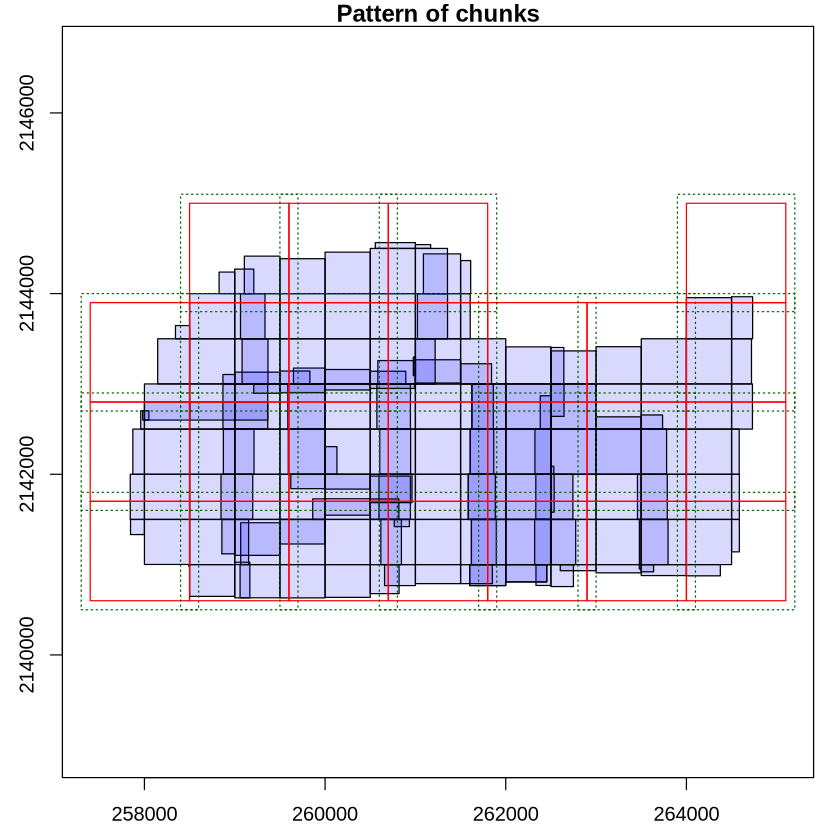

In [3]:
# Define the directory containing the LAS files
data_dir <- "../data/individual"

# List and filter files that contain '.las' in their names
# full.names = TRUE ensures that the function returns the full path names of the files, not just the file names. 
files_sel<- list.files(data_dir, pattern = ".las", full.names = TRUE) 

# selecte the properties to load 
ctg <- readLAScatalog(files_sel)
# opt_select(ctg) <- "xyzicRGB"
opt_select(ctg) <- "xyz"

# Reset classification and ScannerChannel to valid values
# opt_filter(ctg) <- "-drop_z_below 0 -set_classification 0 "

opt_chunk_size(ctg) <- 1100
opt_chunk_buffer(ctg) <- 100
plot(ctg, chunk = TRUE)

summary(ctg)

In [ ]:
las_check(ctg)

# delete duplcates and export 

Chunk 1 of 25 (4%): state ✓
Chunk 2 of 25 (8%): state ✓
Chunk 3 of 25 (12%): state ✓
Chunk 4 of 25 (16%): state ✓
Chunk 5 of 25 (20%): state ✓
Chunk 6 of 25 (24%): state ✓
Chunk 7 of 25 (28%): state ✓
Chunk 8 of 25 (32%): state ✓
Chunk 9 of 25 (36%): state ✓
Chunk 10 of 25 (40%): state ✓
Chunk 11 of 25 (44%): state ✓
Chunk 12 of 25 (48%): state ✓
Chunk 13 of 25 (52%): state ✓
Chunk 14 of 25 (56%): state ✓
Chunk 15 of 25 (60%): state ✓
Chunk 16 of 25 (64%): state ✓
Chunk 17 of 25 (68%): state ✓
Chunk 18 of 25 (72%): state ✓
Chunk 19 of 25 (76%): state ✓
Chunk 20 of 25 (80%): state ✓
Chunk 21 of 25 (84%): state ✓
Chunk 22 of 25 (88%): state ✓
Chunk 23 of 25 (92%): state ✓
Chunk 24 of 25 (96%): state ✓
Chunk 25 of 25 (100%): state ✓
class       : LAScatalog (v1.4 format 7)
extent      : 257843, 264733, 2140632, 2144565 (xmin, xmax, ymin, ymax)
coord. ref. : NA 
area        : 22 kunits²
points      : 8.58 billion points
density     : 389.9 points/units²
density     : 389.9 pulses/units²
nu

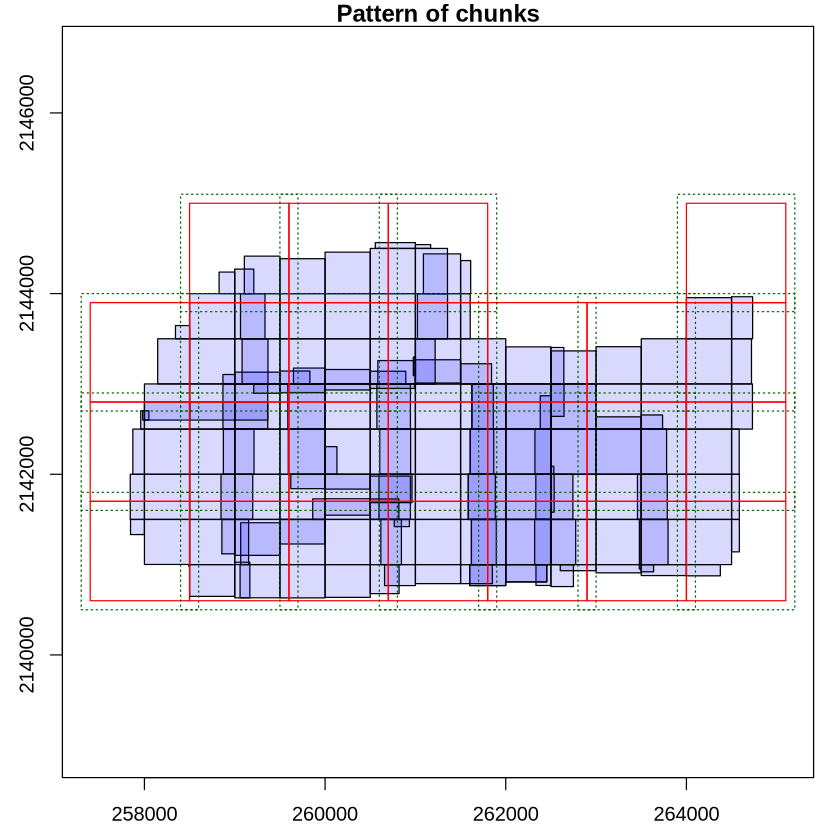

In [4]:
# plan(multisession, workers =10)  # multicore for linux, multisession for windows

filter_dups = function(las) {
  if (is(las, "LAS")) {
    las <- filter_duplicates(las)
    return(las)
  }
  
  if (is(las, "LAScatalog")) {
    options <- list(
      need_output_file = TRUE, # Ensure output template is provided
      need_buffer = FALSE,     # No buffer needed for this operation
      autoresume = TRUE  # Skip processing if output exists,restart kernel restart processing
    )
    res <- catalog_map(las, filter_dups, .options = options)
    return(res)
  }
}


# Set the output directory and file naming convention
opt_output_files(ctg) <- "../run/0_remove_duplicate/remove_duplicate_{XLEFT}_{YBOTTOM}"


# Apply the function to remove duplicates and drop invalid points from each chunk
# catalog_apply(ctg, filter_dups)
ctg = filter_dups(ctg)

summary(ctg)

# denoise_sor (slower)

Be careful, some tiles seem to overlap each other. lidR may return incorrect outputs with edge artifacts when processing this catalog.



class       : LAScatalog (v1.4 format 7)
extent      : 257843, 264733, 2140632, 2144565 (xmin, xmax, ymin, ymax)
coord. ref. : NA 
area        : 22 kunits²
points      : 8.58 billion points
density     : 389.9 points/units²
density     : 389.9 pulses/units²
num. files  : 25 
proc. opt.  : buffer: 100 | chunk: 1100
input opt.  : select: xyz | filter: -drop_z_below 0
output opt. : in memory | w2w guaranteed | merging enabled
drivers     :
 - Raster : format = GTiff  NAflag = -999999  
 - stars : NA_value = -999999  
 - SpatRaster : overwrite = FALSE  NAflag = -999999  
 - SpatVector : overwrite = FALSE  
 - LAS : no parameter
 - Spatial : overwrite = FALSE  
 - sf : quiet = TRUE  
 - data.frame : no parameter


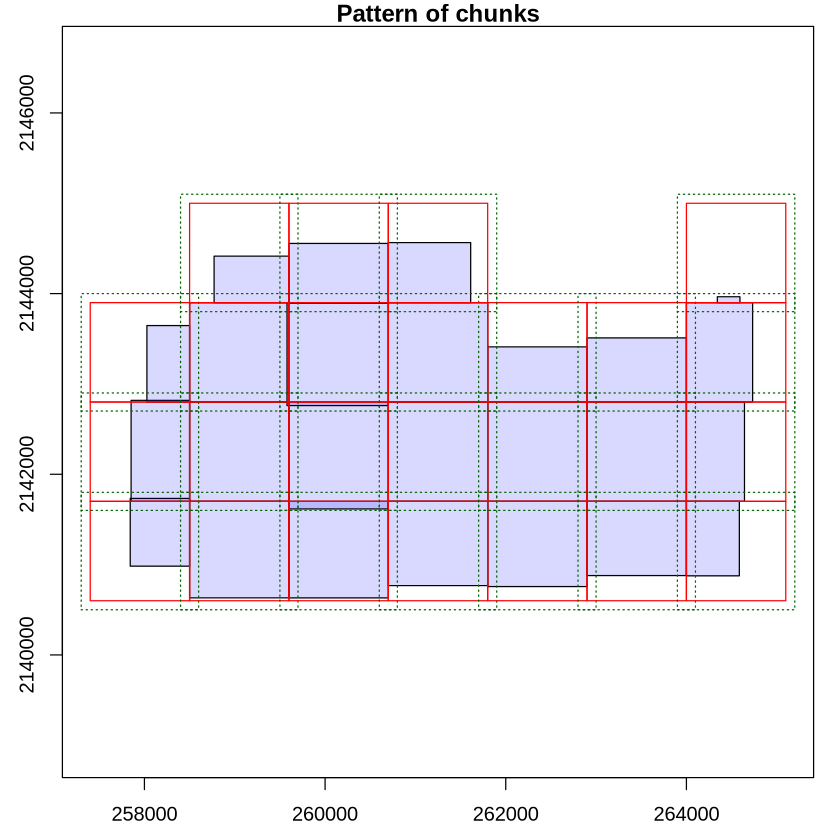

In [4]:
ctg_rdup <- readLAScatalog("../run/0_remove_duplicate/")
opt_select(ctg_rdup) <- "xyz"

# Reset classification and ScannerChannel to valid values
opt_filter(ctg_rdup) <- "-drop_z_below 0"


opt_chunk_size(ctg_rdup) <- 1100
opt_chunk_buffer(ctg_rdup) <- 100
plot(ctg_rdup , chunk = TRUE)
summary(ctg_rdup )

Start time: 2025-04-12 01:17:17 
Chunk 1 of 25 (4%): state ✓
Chunk 2 of 25 (8%): state ✗


An error occurred when processing the chunk 2. Try to load this chunk with:
 chunk <- readRDS("/tmp/Rtmp3zO5on/chunk2.rds")
 las <- readLAS(chunk)

Invalid data: ReturnNumber is not an unsigned integer on 4 bits



End time: 2025-04-12 02:51:56 


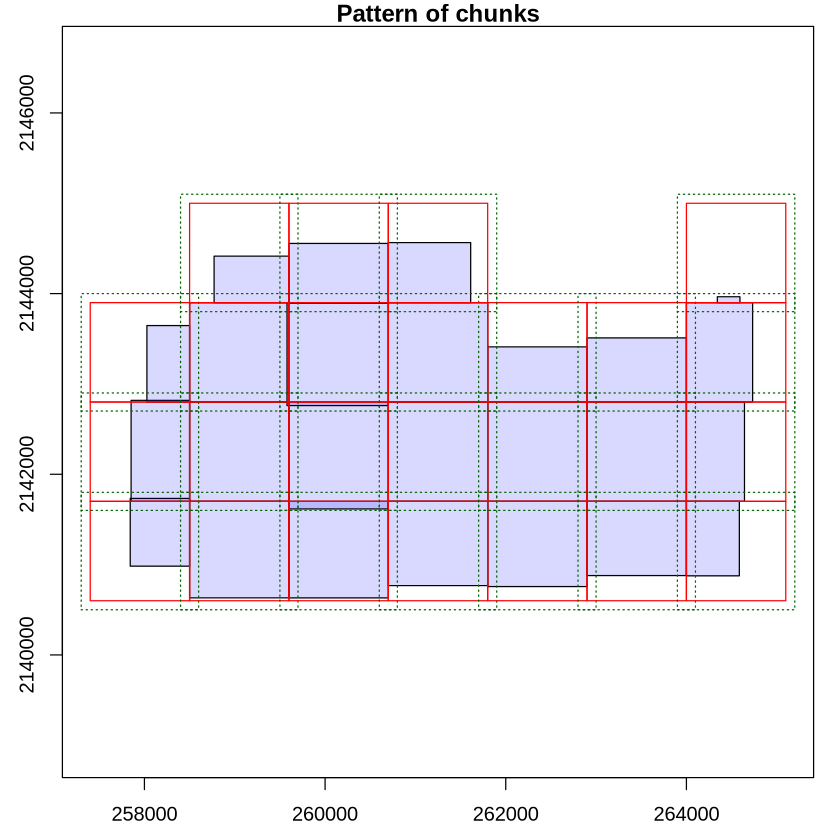

In [5]:

# plan(multisession, workers =2)  # multicore for linux, multisession for windows

# Record start time
start_time <- Sys.time()
cat("Start time:", format(start_time, "%Y-%m-%d %H:%M:%S"), "\n")

# k: number of neighbours; 
# m: Multiplier.The maximum distance will be: avg distance + m * std deviation.

opt_output_files(ctg_rdup) <- "../run/0_denoise_sor/denoise_sor_{XLEFT}_{YBOTTOM}"
opt_filter(ctg_rdup) <- "-drop_class 18"  # Exclude noise points

ctg_sor <- system.time(classify_noise(ctg_rdup, sor(25,5)) )


# Record end time
end_time <- Sys.time()
cat("End time:", format(end_time, "%Y-%m-%d %H:%M:%S"), "\n")



# denoise_ivf (faster)

In [ ]:
ctg_rdup <- readLAScatalog("../run/0_remove_duplicate/")
# opt_select(ctg_rdup) <- "xyzRGB"

# Reset classification and ScannerChannel to valid values
opt_filter(ctg_rdup) <- "-drop_z_below 0 -set_classification 0"


opt_chunk_size(ctg_rdup) <- 500
opt_chunk_buffer(ctg_rdup) <- 60
plot(ctg_rdup , chunk = TRUE)

In [ ]:
# Record start time
start_time <- Sys.time()
cat("Start time:", format(start_time, "%Y-%m-%d %H:%M:%S"), "\n")

plan(multisession, workers =2)  # multicore for linux, multisession for windows

# isolated voxels filter
# ivf finds points that have only a few other points in their surrounding 3 x 3 x 3 = 27 voxels
# 5: Advanced, T., Transformation, F.D., 2020. Package ‘ lidar ’ 2015.
# 2: The maximal number of ’other points’ in the 27 voxels

opt_output_files(ctg_rdup) <- "../run/0_denoise_ivf/denoise_ivf_{XLEFT}_{YBOTTOM}"
opt_filter(ctg_rdup) <- "-drop_class 18"  # Exclude noise points
ctg_ivf  <- system.time(classify_noise(las_rdup, ivf(5,2)) )

# Record end time
end_time <- Sys.time()
cat("End time:", format(end_time, "%Y-%m-%d %H:%M:%S"), "\n")

# select sor-denoised data for next process

class       : LAScatalog (v1.4 format 7)
extent      : 257843, 264733, 2140632, 2144565 (xmin, xmax, ymin, ymax)
coord. ref. : NA 
area        : 21.77 kunits²
points      : 8.54 billion points
density     : 392.3 points/units²
density     : 392.3 pulses/units²
num. files  : 25 
proc. opt.  : buffer: 100 | chunk: 1100
input opt.  : select: * | filter: 
output opt. : in memory | w2w guaranteed | merging enabled
drivers     :
 - Raster : format = GTiff  NAflag = -999999  
 - stars : NA_value = -999999  
 - SpatRaster : overwrite = FALSE  NAflag = -999999  
 - SpatVector : overwrite = FALSE  
 - LAS : no parameter
 - Spatial : overwrite = FALSE  
 - sf : quiet = TRUE  
 - data.frame : no parameter


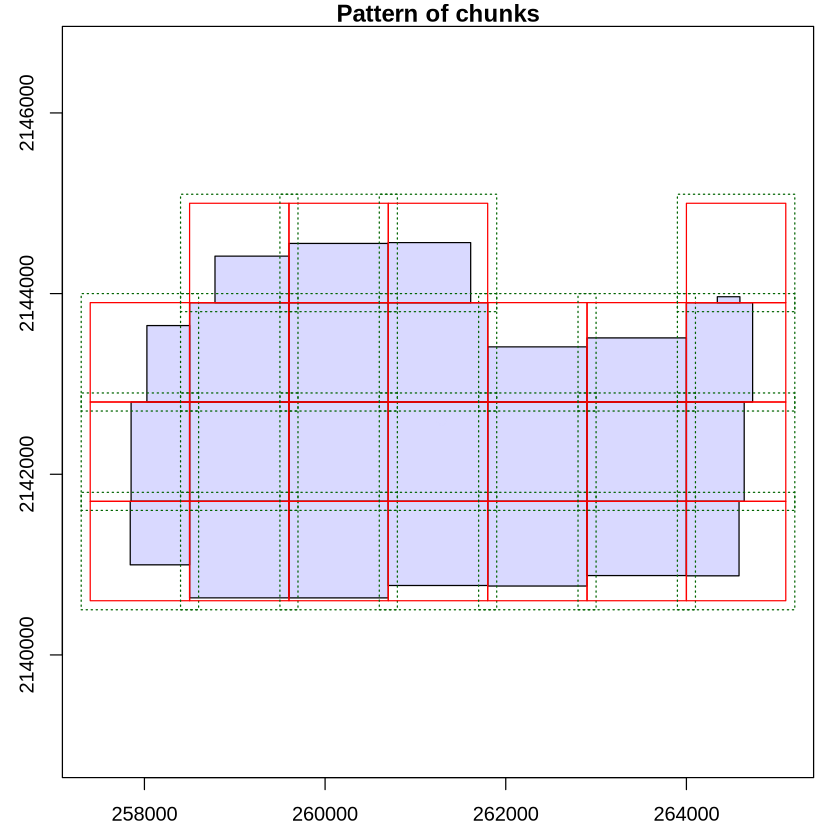

In [3]:
ctg_denoise<- readLAScatalog("../run/0_denoise_sor/")
# opt_select(ctg_rdup) <- "xyz"

# Reset classification and ScannerChannel to valid values
# opt_filter(ctg_denoise) <- "-drop_z_below 0 -set_classification 0 -set_scanner_channel 0"


opt_chunk_size(ctg_denoise) <- 1100
opt_chunk_buffer(ctg_denoise) <- 100
plot(ctg_denoise , chunk = TRUE)
summary(ctg_denoise)

## point density layout

In [ ]:
# Calculate density
density <- pixel_metrics(ctg_denoise, ~length(Z)/1, res =1) 
class(density)

In [ ]:
density

In [ ]:

# 1. Convert SpatRaster to Data Frame
density_df <- as.data.frame(density, xy = TRUE)

# 2. Bin Density Values into Categories
density_df$DensityCat <- cut(
  density_df$V1,
  breaks = c(0,50, 100, 200, 300, 400, 500, Inf),
  labels = c("0-50","50-100", "100-200", "200-300", "300-400", "400-500", ">500"),
  include.lowest = TRUE,
  right = FALSE
)

# 3. Create the Plot
density_plot <- ggplot(data = density_df, aes(x = x, y = y, fill = DensityCat)) +
  geom_tile() +
  scale_fill_manual(
    values = c(
      "0-50"   = "#B2B2B2",  # Light green
      "50-100"   = "#7A7A7A", 
      "100-200" = "#F45B5B",  # Light orange
      "200-300" = "#00FF00",  # Medium orange
      "300-400" = "#4A66AC",  # Bright orange-red
      "400-500" = "#3E1E13",  # Dark red
      ">500"    = "#FFFF00"   # Deep maroon
    ),
    name = "Density (pts/m²)"
  ) +
  coord_equal() +
  labs(
    title = "UAV-Lidar Point Density Map after Deletting Duplicate Point and Denoise",
    # x = "X Coordinate",
    # y = "Y Coordinate"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 16),
    axis.title = element_text(size = 12),
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 10),
    panel.border = element_rect(color = "gray", fill = NA, linewidth = 0.5) # Add plot box
  )

# 4. Save Plot to File
ggsave(
  filename = "../run/density_plot_with_legend.png", # File path
  plot = density_plot,                             # ggplot object
  width = 10,                                      # Width in inches
  height = 8,                                      # Height in inches
  dpi = 600                                        # DPI (dots per inch)
)


## gnd/non-gnd classification via csf

In [ ]:
ctg_denoise<- readLAScatalog("../run/0_denoise_sor/")
opt_select(ctg_denoise) <- "xyz"

# Reset classification and ScannerChannel to valid values
opt_filter(ctg_denoise) <- "-drop_z_below 0 -set_classification 0 -set_scanner_channel 0"
# opt_filter(ctg_denoise) <- "-drop_z_below 0 "
# opt_filter(ctg_denoise) <- "-drop_z_below 0 -set_scanner_channel 0"

opt_chunk_size(ctg_denoise) <- 700
opt_chunk_buffer(ctg_denoise) <- 60
plot(ctg_denoise , chunk = TRUE)
summary(ctg_denoise)

In [ ]:
# plan(multisession, workers =2)  # multicore for linux, multisession for windows

# Define the CSF algorithm parameters
mycsf <- csf(
  sloop_smooth = TRUE, # When steep slopes exist, set this parameter to TRUE
  class_threshold = 0.5,  
  cloth_resolution = 1,  # grid size
  rigidness = 1L,         # Soft cloth (better for slopes/vegetation)
  iterations = 1000L,     # Default iteration count
  time_step = 0.65
)


# Record start time
start_time <- Sys.time()
cat("Start time:", format(start_time, "%Y-%m-%d %H:%M:%S"), "\n")


# Set output files
opt_output_files(ctg_denoise) <- "../run/1_csf/ground_csf_{XLEFT}_{YBOTTOM}"



# Classify ground points using the CSF algorithm
ground_csf <- classify_ground(ctg_denoise, mycsf)


# Filter to export only ground points (classification = 2)
# opt_filter(ctg_denose) <- "-keep_class 2"


# Record end time
end_time <- Sys.time()
cat("End time:", format(end_time, "%Y-%m-%d %H:%M:%S"), "\n")

# Calculate execution time
execution_time <- difftime(end_time, start_time)
cat("Execution time:", round(execution_time, 2), attributes(execution_time)$units, "\n")


# Summarize the results (triggers processing)
summary(ground_csf)



## save ground

In [ ]:
# export ground points
# Create ground points catalog
ctg_ground <- readLAScatalog("../run/1_csf/")

opt_filter(ctg_ground) <- "-keep_class 2"
opt_output_files(ctg_ground) <- "../run/1_ground/ground_{XLEFT}_{YBOTTOM}"


# Process both catalogs
catalog_retile(ctg_ground)

## save non-ground

In [ ]:
# export non-ground points
# Create non-ground points catalog
ctg_nonground <- readLAScatalog("../run/1_csf/")
opt_filter(ctg_nonground) <- "-drop_class 2"
opt_output_files(ctg_nonground) <- "../run/1_non_ground/nonground_{XLEFT}_{YBOTTOM}"

# Process both catalogs
catalog_retile(ctg_nonground)



# dtm through tin

In [ ]:
ctg_ground<- readLAScatalog("../run/1_ground/")
# opt_select(ctg_class) <- "xyzc"

# Reset classification and ScannerChannel to valid values
# opt_filter(ctg_class) <- "-set_scanner_channel 0L"

opt_chunk_size(ctg_ground) <- 500
opt_chunk_buffer(ctg_ground) <- 60
plot(ctg_ground, chunk = TRUE)
summary(ctg_ground)

In [ ]:
# plan(multisession, workers =2L)  # multicore for linux, multisession for windows

opt_output_files(ctg_ground) <- "../run/2_dtm_tin/dtm_tin_{XLEFT}_{YBOTTOM}"
dtm_tin <- rasterize_terrain(ctg_ground, 0.1, tin(), overwrite='TRUE')
dtm_tin

In [ ]:
vrt_tin <- rast("../run/2_dtm_tin/rasterize_terrain.vrt")
writeRaster(vrt_tin, "../run/2_dtm_tin/dtm_tin_mosaic.tif", overwrite = TRUE)

# dsm through tin

In [ ]:
ctg_non_ground<- readLAScatalog("../run/1_non_ground/")
# opt_select(ctg_class) <- "xyzc"

# Reset classification and ScannerChannel to valid values
# opt_filter(ctg_class) <- "-set_scanner_channel 0L"

opt_chunk_size(ctg_non_ground) <- 500
opt_chunk_buffer(ctg_non_ground) <- 60
plot(ctg_non_ground, chunk = TRUE)
summary(ctg_non_ground)

In [ ]:
# plan(multisession, workers =5L)  # multicore for linux, multisession for windows

opt_output_files(ctg_non_ground) <- "../run/3_dsm_tin/dsm_tin_{XLEFT}_{YBOTTOM}"
dsm_tin <- rasterize_canopy(ctg_non_ground, 0.1, algorithm = dsmtin(), overwrite='TRUE')
dsm_tin


In [ ]:
vrt_dsm_tin<- rast("../run/3_dsm_tin/rasterize_canopy.vrt")
writeRaster(vrt_dsm_tin, "../run/3_dsm_tin/dsm_tin_mosaic.tif", overwrite = TRUE)

# height normalization

## height normalization via dtm

In [ ]:
ctg_class<- readLAScatalog("../run/1_ground/")
opt_select(ctg_class) <- "xyz"

opt_chunk_size(ctg_class) <- 1100
opt_chunk_buffer(ctg_class) <- 100
plot(ctg_class, chunk = TRUE)
summary(ctg_class)


In [ ]:
# load dtm
dtm <- rast("../run/2_dtm_tin/dtm_tin_mosaic.tif")
dtm

In [ ]:
# plan(multisession, workers =2L)  # multicore for linux, multisession for windows

opt_output_files(ctg_class) <-  "../run/4_height_normalization_dtm/norm_{XLEFT}_{YBOTTOM}"
ctg_norm_dtm <- normalize_height(ctg_class, dtm)

## height normalization via tin

In [ ]:
ctg_class<- readLAScatalog("../run/1_csf/")
opt_select(ctg_class) <- "xyzc"

# Reset classification and ScannerChannel to valid values
# opt_filter(ctg_class) <- "-set_scanner_channel 0L"

opt_chunk_size(ctg_class) <- 500
opt_chunk_buffer(ctg_class) <- 60
plot(ctg_class, chunk = TRUE)
summary(ctg_class)


In [ ]:
# plan(multicore, workers =5L)  # multicore for linux, multisession for windows

opt_output_files(ctg_class) <- "../run/4_height_normalization_tin/norm_{XLEFT}_{YBOTTOM}"


norm_ctg_tin <- normalize_height(ctg_class, algorithm=tin()) # , use_class = c(2L))


# CHM 

## CHM (through normalization via dtm)

class       : LAScatalog (v1.4 format 7)
extent      : 257843, 264733, 2140632, 2144565 (xmin, xmax, ymin, ymax)
coord. ref. : NA 
area        : 21.77 kunits²
points      : 8.54 billion points
density     : 392.3 points/units²
density     : 392.3 pulses/units²
num. files  : 25 
proc. opt.  : buffer: 100 | chunk: 1100
input opt.  : select: xyz | filter: -drop_z_below 0
output opt. : in memory | w2w guaranteed | merging enabled
drivers     :
 - Raster : format = GTiff  NAflag = -999999  
 - stars : NA_value = -999999  
 - SpatRaster : overwrite = FALSE  NAflag = -999999  
 - SpatVector : overwrite = FALSE  
 - LAS : no parameter
 - Spatial : overwrite = FALSE  
 - sf : quiet = TRUE  
 - data.frame : no parameter


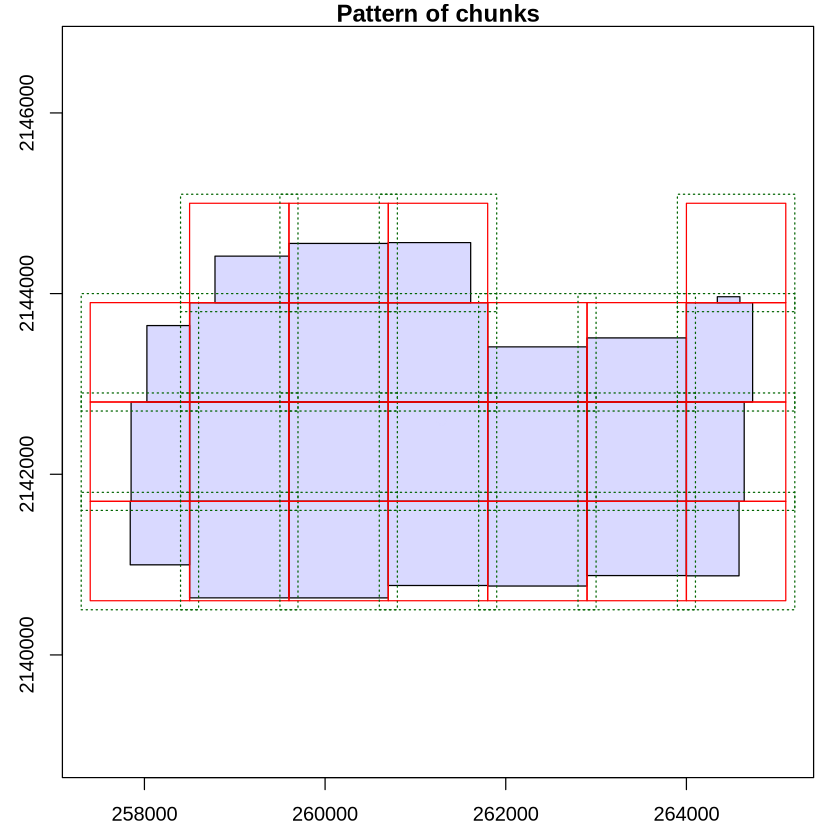

In [5]:

ctg_norm_dtm<- readLAScatalog("../run/4_height_normalization_dtm/")

opt_select(ctg_norm_dtm) <- "xyz"

# Reset filter
# opt_filter(ctg_norm_dtm) <- "-drop_z_below 0 -drop_z_above 100"
opt_filter(ctg_norm_dtm) <- "-drop_z_below 0"
opt_chunk_size(ctg_norm_dtm) <- 1100
opt_chunk_buffer(ctg_norm_dtm) <- 100
plot(ctg_norm_dtm, chunk = TRUE)
summary(ctg_norm_dtm)


Chunk 1 of 25 (4%): state ✓
Chunk 2 of 25 (8%): state ✓
Chunk 3 of 25 (12%): state ✓
Chunk 4 of 25 (16%): state ✓
Chunk 5 of 25 (20%): state ✓
Chunk 6 of 25 (24%): state ✓
Chunk 7 of 25 (28%): state ✓
Chunk 8 of 25 (32%): state ✓
Chunk 9 of 25 (36%): state ✓
Chunk 10 of 25 (40%): state ✓
Chunk 11 of 25 (44%): state ✓
Chunk 12 of 25 (48%): state ✓
Chunk 13 of 25 (52%): state ✓
Chunk 14 of 25 (56%): state ✓
Chunk 15 of 25 (60%): state ✓
Chunk 16 of 25 (64%): state ✓
Chunk 17 of 25 (68%): state ✓
Chunk 18 of 25 (72%): state ✓
Chunk 19 of 25 (76%): state ✓
Chunk 20 of 25 (80%): state ✓
Chunk 21 of 25 (84%): state ✓
Chunk 22 of 25 (88%): state ✓


Warning message:
“Invalid file: the header states the file contains 246197998 returns numbered '1' but 246197997 were found.”


Chunk 23 of 25 (92%): state ⚠
Chunk 24 of 25 (96%): state ✓
Chunk 25 of 25 (100%): state ✓


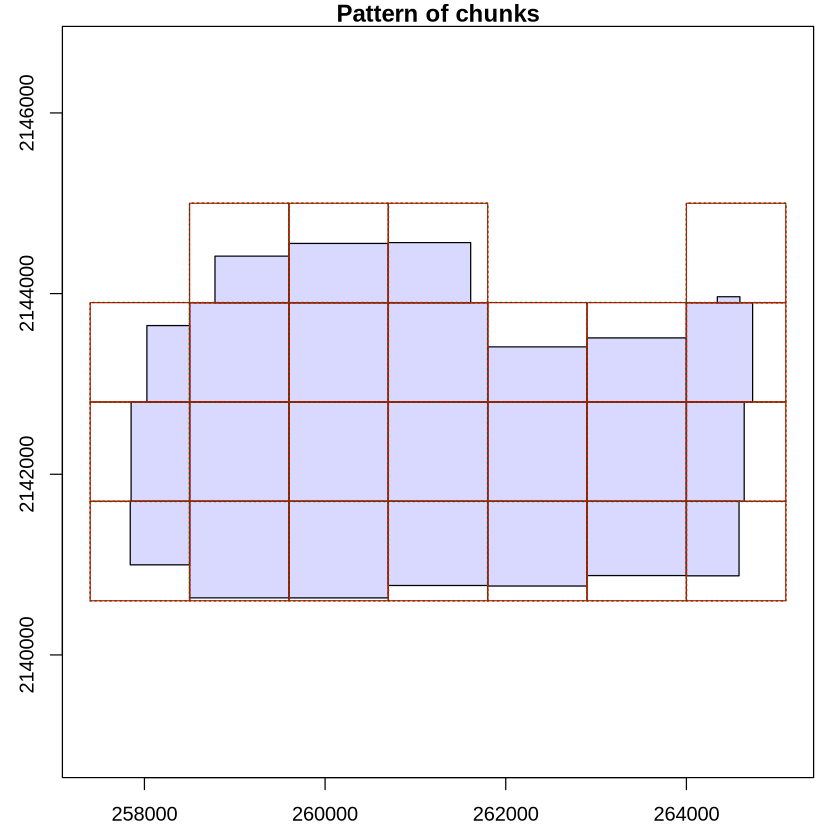

In [6]:
# plan(multisession, workers =5L) 

opt_output_files(ctg_norm_dtm) <- '../run/5_chm_normalization_dtm/chm_dtm_tin_{XLEFT}_{YBOTTOM}'
chm_dtm <- rasterize_canopy(ctg_norm_dtm, res = 1, algorithm = dsmtin(), overwrite=TRUE)


In [7]:
vrt_chm_dtm <- rast("../run/5_chm_normalization_dtm/rasterize_canopy.vrt")
writeRaster(vrt_chm_dtm, "../run/5_chm_normalization_dtm/chm_dtm_tin_mosaic.tif", overwrite = TRUE)

In [8]:
# Create a mask where values are >= 0
mask_raster <- vrt_chm_dtm >= 0

# Apply the mask
chm_corrected <- mask(vrt_chm_dtm, mask_raster, maskvalue = FALSE)

writeRaster(chm_corrected, "../run/5_chm_normalization_dtm/chm_dtm_tin_mosaic_corrected.tif", overwrite = TRUE)

## CHM (through normalization via tin)

In [ ]:

ctg_norm_tin<- readLAScatalog("../run/4_height_normalization_tin/")
# opt_select(ctg_norm_tin) <- "xyzc"

# Reset filter
opt_filter(ctg_norm_tin) <- "-drop_z_below 0 -drop_z_above 100"

opt_chunk_size(ctg_norm_tin) <- 500
opt_chunk_buffer(ctg_norm_tin) <- 60
plot(ctg_norm_tin, chunk = TRUE)
summary(ctg_norm_tin)


In [ ]:
# plan(multisession, workers =5L) 

opt_output_files(ctg_norm_tin) <- '../run/5_chm_normalization_tin/chm_tin_tin_{XLEFT}_{YBOTTOM}'
chm_tin <- rasterize_canopy(ctg_norm_tin, res = 0.1, algorithm = dsmtin(), overwrite=TRUE)


In [ ]:
vrt_chm_tin <- rast("../run/5_chm_normalization_tin/rasterize_canopy.vrt")
writeRaster(vrt_chm_tin, "../run/5_chm_normalization_tin/chm_tin_tin_mosaic.tif", overwrite = TRUE)

In [ ]:
# Create a mask where values are >= 0
mask_raster <- vrt_chm_tin  >= 0

# Apply the mask
chm_corrected <- mask(vrt_chm_tin, mask_raster, maskvalue = FALSE)

writeRaster(chm_corrected, "../run/5_chm_normalization_tin/chm_tin_tin_mosaic_corrected.tif", overwrite = TRUE)

# smoothing (median filter)

## tin normalized chm

In [ ]:
# load dtm
chm_dtm_tin <- rast("../run/5_chm_normalization_tin/chm_tin_tin_mosaic_corrected.tif")

# Define filter size
filter_size <- 5  # Set this to control matrix dimensions
filter_matrix <- matrix(1, filter_size, filter_size)

# Apply median filter with specified matrix size
chm_dtm_tin_smooth <- focal(
  chm_dtm_tin,
  w = filter_matrix,
  fun = median,
  na.rm = TRUE
)

# Set the CRS to WGS 84 / UTM zone 14N
crs(chm_dtm_tin_smooth) <- "EPSG:32614"

# Export with matrix size in filename
output_name <- paste0(
  "../run/6_smooth/chm_dtm_tin_mosaic_corrected_smoothed_wgs198514n_",
  filter_size, "x", filter_size, ".tif"
)

writeRaster(chm_dtm_tin_smooth, 
            filename = output_name, 
            overwrite = TRUE
           )


### plot chm

In [ ]:
# Display the smoothed raster
plot(chm_dtm_tin_smooth, 
     col =  viridis::turbo(255),
     plg = list(title = "Height (m)", cex = 0.8),
     main = paste("CHM -", filter_size, "x", filter_size, "Median Filter")
    )



### save plot

In [ ]:
### # Create the PNG file with specified dimensions

output_png <- paste0(
  "../run/6_smooth/smoothed_median_plot_", 
  filter_size, "x", filter_size, ".png"
)

png(filename = output_png,
    width = 12, 
    height = 8, 
    units = "in", 
    res = 600
   )

# Plot the smoothed raster
plot(chm_dtm_tin_smooth, 
     col = viridis::turbo(255),
     plg = list(title = "Height (m)", cex = 0.8),
     main = paste("CHM -", filter_size, "x", filter_size, "Median Filter")
    )

# Save the plot
dev.off()

## dtm normalized chm

In [4]:
# load dtm
chm_dtm_tin <- rast("../run/5_chm_normalization_dtm_1m/chm_dtm_tin_mosaic_corrected.tif")

# Define filter size
filter_size <- 5  # Set this to control matrix dimensions
filter_matrix <- matrix(1, filter_size, filter_size)

# Apply median filter with specified matrix size
chm_dtm_tin_smooth <- focal(
  chm_dtm_tin,
  w = filter_matrix,
  fun = median,
  na.rm = TRUE
)


# Set the CRS to WGS 84 / UTM zone 14N
crs(chm_dtm_tin_smooth) <- "EPSG:32614"

# Export with matrix size in filename
output_name <- paste0(
  "../run/6_smooth/chm_dtm_tin_mosaic_corrected_smoothed_wgs198414n_",
  filter_size, "x", filter_size, ".tif"
)

writeRaster(chm_dtm_tin_smooth, 
            filename = output_name, 
            overwrite = TRUE
           )


### plot chm

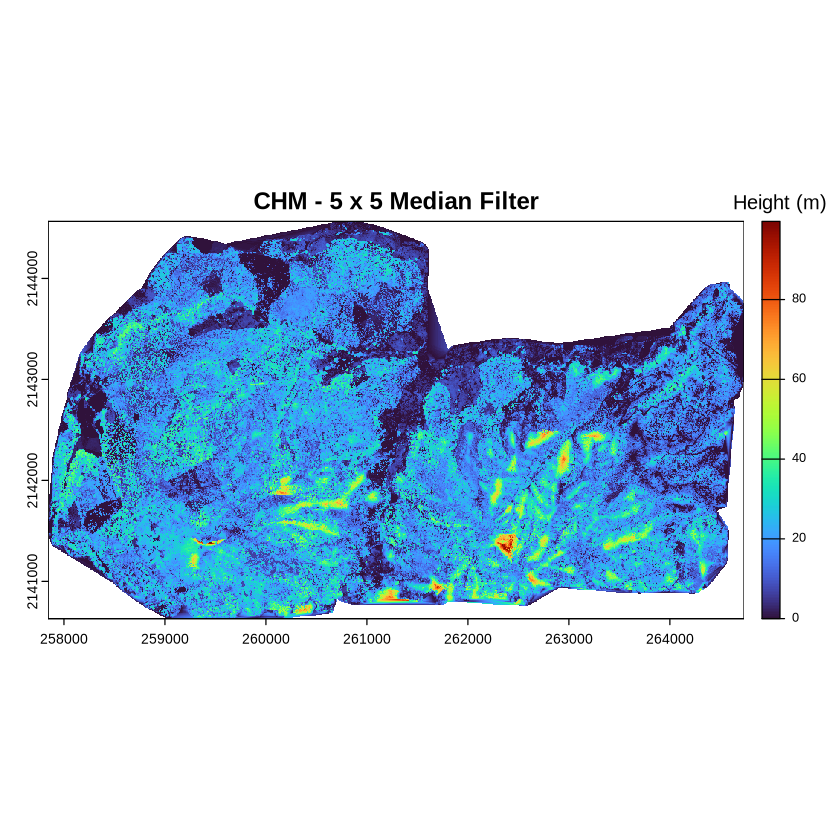

In [5]:
# Display the smoothed raster
plot(chm_dtm_tin_smooth, 
     col =  viridis::turbo(255),
     plg = list(title = "Height (m)", cex = 0.8),
     main = paste("CHM -", filter_size, "x", filter_size, "Median Filter")
    )


### save plot

In [6]:
### # Create the PNG file with specified dimensions

output_png <- paste0(
  "../run/6_smooth/smoothed_median_plot_wgs198414n", 
  filter_size, "x", filter_size, ".png"
)

png(filename = output_png,
    width = 12, 
    height = 8, 
    units = "in", 
    res = 600
   )

# Plot the smoothed raster
plot(chm_dtm_tin_smooth, 
     col = viridis::turbo(255),
     plg = list(title = "Height (m)", cex = 0.8),
     main = paste("CHM -", filter_size, "x", filter_size, "Median Filter")
    )

# Save the plot
dev.off()

pdf 
  2

# retiling

In [ ]:
# Read the LAS catalog
ctg_class <- readLAScatalog("../run/1_csf/")

# Set the options for chunk size and buffer
opt_chunk_size(ctg_class) <- 4400
opt_chunk_buffer(ctg_class) <- 200
plot(ctg_class, chunk = TRUE)
summary(ctg_class)


In [ ]:
opt_output_files(ctg_class) <- "../run/retiling/_test/{XLEFT}_{YBOTTOM}"

newctg = catalog_retile(ctg_class)
plot(newctg)